Samuel Scott
ADS 505 - Applied Data Science for Business
Module 1 Assignment 1.1: Use Case - Charles Book Club

In [1]:
#Check Python version
!python --version

Python 3.13.5


In [2]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

Instructions
Complete all questions in a single Jupyter notebook.
Include the question number and full question text as a Markdown cell above each answer.
Show all code, output, and interpretation. Add inline comments explaining non-obvious decisions

#Introducing data and Preprocessing data

In [3]:
#Importing data sets
cbc_df = pd.read_csv('C:/Users/samsc/Desktop/ADS-505/CharlesBookClub.csv')
cbc_df.head()

,Seq#,ID#,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,...,ItalCook,ItalAtlas,ItalArt,Florence,Related Purchase,Mcode,Rcode,Fcode,Yes_Florence,No_Florence
0,1,25,1,297,14,2,22,0,1,1,...,0,0,0,0,0,5,4,2,0,1
1,2,29,0,128,8,2,10,0,0,0,...,0,0,0,0,0,4,3,2,0,1
2,3,46,1,138,22,7,56,2,1,2,...,1,0,0,0,2,4,4,3,0,1
3,4,47,1,228,2,1,2,0,0,0,...,0,0,0,0,0,5,1,1,0,1
4,5,51,1,257,10,1,10,0,0,0,...,0,0,0,0,0,5,3,1,0,1


In [4]:
cbc_df.shape

(4000, 24)

In [5]:
#No NA values in this dataset which is important to note for preprocessing
cbc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Seq#              4000 non-null   int64
 1   ID#               4000 non-null   int64
 2   Gender            4000 non-null   int64
 3   M                 4000 non-null   int64
 4   R                 4000 non-null   int64
 5   F                 4000 non-null   int64
 6   FirstPurch        4000 non-null   int64
 7   ChildBks          4000 non-null   int64
 8   YouthBks          4000 non-null   int64
 9   CookBks           4000 non-null   int64
 10  DoItYBks          4000 non-null   int64
 11  RefBks            4000 non-null   int64
 12  ArtBks            4000 non-null   int64
 13  GeogBks           4000 non-null   int64
 14  ItalCook          4000 non-null   int64
 15  ItalAtlas         4000 non-null   int64
 16  ItalArt           4000 non-null   int64
 17  Florence          4000 non-null  

##Question 1 - RFM Segmentation

###1.1 Partition the data into training (60%) and validation (40%). Use seed = 1.

In [6]:
trainData, validationData = train_test_split(cbc_df, test_size = 0.4, random_state=4)

In [7]:
#Check to see if data distribution is correct
print(trainData.shape)
print(validationData.shape)

(2400, 24)
(1600, 24)


###1.2 What is the response rate for the training data customers taken as a whole? What is the
response rate for each of the 4 x 5 x 3 = 60 combinations of RFM categories? Which
combinations have response rates in the training data that are above the overall response in the
training data?

###1.2.1 What is the response rate for the training data customers taken as a whole?

In [8]:
overall_response = trainData['Yes_Florence'].sum()/ trainData['Yes_Florence'].shape[0] #Overall response rate 162/1800
overall_response

np.float64(0.08708333333333333)

The second question digs more into these customers who said yes. What is their RFM scores as customers. Are they recent and frequent buyers of books? How much money have they spent? Let's make these yes customer a dataframe or series and make these yes customers from a boolean mask. 

In [9]:
train_response_rate = trainData[trainData['Yes_Florence'] == 1]
train_response_rate

,Seq#,ID#,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,...,ItalCook,ItalAtlas,ItalArt,Florence,Related Purchase,Mcode,Rcode,Fcode,Yes_Florence,No_Florence
657,658,5870,0,81,16,1,16,0,0,0,...,0,0,0,1,0,3,4,1,1,0
3128,3129,25828,1,267,14,2,22,2,0,0,...,0,0,0,1,0,5,4,2,1,0
510,511,4653,0,258,28,7,60,0,1,1,...,1,0,1,1,6,5,4,3,1,0
1893,1894,15693,1,64,14,2,16,0,0,0,...,0,0,0,1,0,3,4,2,1,0
2112,2113,17436,0,189,20,1,20,0,0,0,...,0,0,0,1,1,4,4,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246,2247,18507,1,183,14,2,22,0,0,0,...,0,0,0,1,0,4,4,2,1,0
243,244,2124,1,441,10,12,72,2,1,0,...,0,0,0,1,5,5,3,3,1,0
680,681,6013,1,143,14,1,14,0,0,0,...,0,0,0,1,0,4,4,1,1,0
3394,3395,28084,1,167,10,1,10,0,0,0,...,0,0,0,1,0,4,3,1,1,0


These lines of code do not answer the questions 2 and three for section 1.2. However they helped me understand the Rcode brackets and got me thinking
about how to solve the later questions:

In [10]:
# Customers shop and buy these types of books around every 7-12 months mostly
avg_months_for_yes_cust= train_response_rate['Rcode'].mean() 
avg_months_for_yes_cust

np.float64(3.028708133971292)

In [11]:
# Customers who bought around 2 items from CBC are most likely to say yes to the Florence book
avg_freq_purch_for_yes_cust = train_response_rate['Fcode'].mean() 
avg_freq_purch_for_yes_cust

np.float64(2.2057416267942584)

In [12]:
# Customers who said yes are likely to already have spent around $101-$200
# which is bracket 4 out of the 5 bracket choices for Mcode
avg_money_spent_for_yes_cust = train_response_rate['Mcode'].mean() 
avg_money_spent_for_yes_cust

np.float64(4.363636363636363)

###1.2.2 What is the response rate for each of the 4 x 5 x 3 = 60 combinations of RFM categories? In other words what is the propensity of customers saying yes to each bracket of RFM scores?

In [13]:
#Creating the combinations
#create new feature
#Microsoft Copilot AI help me create this
trainData['RFM_combinations'] = (
    trainData['Rcode'].astype(str) + "_" +
    trainData['Fcode'].astype(str) + "_" +
    trainData['Mcode'].astype(str)
)

In [14]:
#Microsoft Copilot AI help me with this too
#The groupby function is more generalize grouping. We are grouping all the response rates which is the ['Yes_Florence'].mean() by all the combinations
#were made in this last code segment.
rfm_response_rates = trainData.groupby('RFM_combinations')['Yes_Florence'].mean().sort_values(ascending=False)
rfm_response_rates

RFM_combinations
1_2_2    0.500000
2_3_3    0.500000
2_1_1    0.333333
1_1_4    0.250000
2_1_2    0.181818
4_1_2    0.157895
1_3_5    0.152542
2_1_5    0.148148
2_2_2    0.142857
3_3_5    0.137441
2_3_5    0.133333
1_3_4    0.125000
2_2_3    0.117647
1_2_5    0.115385
2_2_5    0.108108
3_3_4    0.105263
4_1_4    0.103774
3_1_1    0.100000
3_1_4    0.098765
2_3_4    0.093023
4_3_4    0.092593
4_3_5    0.085526
3_2_4    0.083333
2_2_4    0.083333
3_2_3    0.083333
4_1_5    0.078740
3_2_2    0.076923
3_1_2    0.071429
1_2_4    0.066667
4_2_2    0.066667
4_1_3    0.064516
4_2_5    0.063830
3_1_5    0.056075
4_3_3    0.052632
3_2_5    0.046296
4_2_4    0.045802
2_1_4    0.041667
1_1_5    0.040000
4_2_3    0.037736
3_1_3    0.027027
1_1_1    0.000000
2_1_3    0.000000
1_3_3    0.000000
1_1_2    0.000000
1_2_3    0.000000
1_1_3    0.000000
4_1_1    0.000000
3_3_3    0.000000
4_3_2    0.000000
Name: Yes_Florence, dtype: float64

###1.2.3 Which combinations have response rates in the training data that are above the overall response in the
training data?

In [15]:
combinations_above_overall = rfm_response_rates[rfm_response_rates > overall_response]
combinations_above_overall 

RFM_combinations
1_2_2    0.500000
2_3_3    0.500000
2_1_1    0.333333
1_1_4    0.250000
2_1_2    0.181818
4_1_2    0.157895
1_3_5    0.152542
2_1_5    0.148148
2_2_2    0.142857
3_3_5    0.137441
2_3_5    0.133333
1_3_4    0.125000
2_2_3    0.117647
1_2_5    0.115385
2_2_5    0.108108
3_3_4    0.105263
4_1_4    0.103774
3_1_1    0.100000
3_1_4    0.098765
2_3_4    0.093023
4_3_4    0.092593
Name: Yes_Florence, dtype: float64

Most of the customers who are likely to buy the new Art of Florence book are recent customers who frequent purchase items from Charles Book Club as a lot of the R values in the RFM combinations are 1's and 2's. Catering to Recency might be the trend since the other columns are most evenly disperse in terms of who is responding to this certain book. 

###1.3 Suppose that we decide to send promotional mail only to the "above-average" RFM
combinations identified in part 1.2. Compute the response rate in the validation data using these
combinations.

In [16]:
overall_response_val = validationData['Yes_Florence'].sum()/ validationData['Yes_Florence'].shape[0] #Overall response val rate 102/1400
overall_response_val

np.float64(0.080625)

In [17]:
validationData['RFM_combinations'] = (
    validationData['Rcode'].astype(str) + "_" +
    validationData['Fcode'].astype(str) + "_" +
    validationData['Mcode'].astype(str)
)

In [18]:
val_response_rates_comb = validationData.groupby('RFM_combinations')['Yes_Florence'].mean().sort_values(ascending=False)
val_response_rates_comb

RFM_combinations
1_3_2    1.000000
1_3_3    0.500000
2_1_1    0.500000
2_1_2    0.333333
2_1_3    0.333333
1_2_2    0.333333
3_1_1    0.250000
2_3_4    0.208333
1_1_5    0.200000
1_3_5    0.200000
1_1_2    0.200000
2_3_5    0.178571
4_1_3    0.170213
2_3_3    0.166667
3_3_5    0.157534
2_2_4    0.115385
1_1_4    0.111111
2_2_3    0.100000
2_2_5    0.100000
2_1_5    0.090909
4_3_3    0.083333
3_2_4    0.083333
4_2_5    0.081633
3_1_2    0.062500
3_3_3    0.062500
4_3_4    0.062500
4_3_5    0.061856
3_1_3    0.052632
4_2_3    0.051282
4_2_4    0.046154
3_3_4    0.043478
3_2_3    0.043478
4_1_4    0.041667
4_1_5    0.037975
2_1_4    0.035714
3_2_5    0.030303
3_1_4    0.018519
3_1_5    0.013158
1_2_5    0.000000
1_2_3    0.000000
1_1_3    0.000000
1_1_1    0.000000
1_2_4    0.000000
2_2_2    0.000000
1_3_4    0.000000
3_3_2    0.000000
3_2_2    0.000000
4_1_2    0.000000
4_1_1    0.000000
4_2_2    0.000000
4_3_2    0.000000
Name: Yes_Florence, dtype: float64

In [19]:
val_combinations_above_overall = val_response_rates_comb[val_response_rates_comb > overall_response_val]
val_combinations_above_overall

RFM_combinations
1_3_2    1.000000
1_3_3    0.500000
2_1_1    0.500000
2_1_2    0.333333
2_1_3    0.333333
1_2_2    0.333333
3_1_1    0.250000
2_3_4    0.208333
1_1_5    0.200000
1_3_5    0.200000
1_1_2    0.200000
2_3_5    0.178571
4_1_3    0.170213
2_3_3    0.166667
3_3_5    0.157534
2_2_4    0.115385
1_1_4    0.111111
2_2_3    0.100000
2_2_5    0.100000
2_1_5    0.090909
4_3_3    0.083333
3_2_4    0.083333
4_2_5    0.081633
Name: Yes_Florence, dtype: float64

Commentary

##Question 2 - k-Nearest Neighbors
The k-NN technique can be used to create segments based on product proximity to similar
products of the products offered as well as the propensity to purchase (as measured by the RFM
variables). For The Art History of Florence, a possible segmentation by product proximity could
be created using the following five variables:

• R: Recency - months since last purchase
• F: Frequency - total number of past purchases
• M: Monetary - total money (in dollars) spent on books
• FirstPurch: Months since first purchase
• RelatedPurch: Total number of past purchases of related books (sum of purchases from
art and geography categories and of titles Secrets of Italian Cooking, Historical Atlas of
Italy, and Italian Art)



###2.1 Use the k-NN approach with uniform weights to classify cases with k = 1, 2, ..., 11, using
Florence as the outcome variable. Based on the validation set, find the best k. Remember to
normalize all five variables. Create a lift curve for the best k model, and report the expected lift for
an equal number of customers from the validation dataset.

See sklearn.neighbors.KNeighborsClassifier documentation for how to assign different weight
functions: https://scikit-
learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

In [20]:
validationData.head()

,Seq#,ID#,Gender,M,R,F,FirstPurch,ChildBks,YouthBks,CookBks,...,ItalAtlas,ItalArt,Florence,Related Purchase,Mcode,Rcode,Fcode,Yes_Florence,No_Florence,RFM_combinations
3264,3265,26897,1,139,10,2,18,1,0,0,...,0,0,0,0,4,3,2,0,1,3_2_4
2559,2560,21147,0,58,36,1,36,0,0,0,...,0,0,1,0,3,4,1,1,0,4_1_3
15,16,121,1,256,14,9,58,2,0,3,...,1,1,0,6,5,4,3,0,1,4_3_5
1872,1873,15468,1,155,2,10,24,0,0,1,...,0,0,0,0,4,1,3,0,1,1_3_4
491,492,4469,1,105,12,7,26,3,0,2,...,0,0,0,0,4,3,3,0,1,3_3_4


In [21]:
#Using the predictors and outcome for the KNN classifier
predictors = ['R', 'F', 'M', 'FirstPurch', 'Related Purchase']
outcome = 'Yes_Florence'
X_train = trainData[predictors]
y_train = trainData[outcome]
X_val = validationData[predictors]
y_val = validationData[outcome]

In [22]:
#combine scaling and KNN classifier into model using pipeline
knn_model = Pipeline([
    ('knn_scaler', preprocessing.StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=11, weights='uniform'))
])
knn_model.fit(X_val, y_val)

Pipeline(steps=[('knn_scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=11))])

In [23]:
knn_results = []
for k in range(1, 12):
    knn_model.set_params(knn__n_neighbors=k)
    accuracy = cross_val_score(knn_model, X_val, y_val, cv=LeaveOneOut(),
                                scoring='accuracy').mean()
    knn_results.append({"k": k, 'accuracy': accuracy})
knn_results = pd.DataFrame(knn_results).round(2)

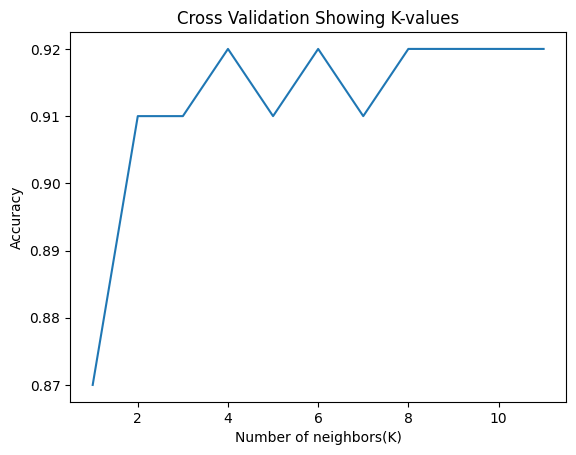

In [24]:
plt.plot(knn_results['k'], knn_results['accuracy'])
plt.title("Cross Validation Showing K-values");
plt.xlabel('Number of neighbors(K)')
plt.ylabel('Accuracy');

In [25]:
#knn optimal model
knn_optimal = Pipeline([ 
    ('scaler' , preprocessing.StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=4)),
])
knn_optimal.fit(X_val, y_val)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=4))])

In [26]:
proba = knn_optimal.predict_proba(X_val)[:, 1] #this is a vector put it in a df so we can sort the values

lift_df = pd.DataFrame({
    'actual': y_val,
    'probability': proba
})
#sort t
lift_df = lift_df.sort_values(by='probability', ascending=False)
lift_df

,actual,probability
824,1,0.75
874,0,0.75
1256,1,0.75
664,1,0.75
2969,1,0.75
...,...,...
15,0,0.00
1872,0,0.00
1307,0,0.00
1055,0,0.00


In [27]:
#https://www.geeksforgeeks.org/data-analysis/understanding-gain-chart-and-lift-chart/ This website help me understand what a lift curve is.
#I used AI to help me implement the lift equation for this data. 

#lift equation: Lift= Cumulative number of positive observations upto decile i using random model/
                     #Cumulative number of positive observations upto decile i using ML model

lift_df['cumulative_actual'] = lift_df['actual'].cumsum() #cumulative sum is stacking percents together by adding them one by one.
#We do this to get a steady rate in the plot.

total_positives = lift_df['actual'].sum() 

#the cumulative gain tells us how many customers we can potentially find and target based on the cumsum
lift_df['cumulative_gain'] = ( 
    lift_df['cumulative_actual'] / total_positives
)

#shows where in the ranking order of customers are you (first being very likely; last being not likely)
lift_df['percent_customers'] = ( 
    (np.arange(len(lift_df)) + 1) / len(lift_df)
)

lift_df['lift'] = (
    lift_df['cumulative_gain'] /
    lift_df['percent_customers']
)

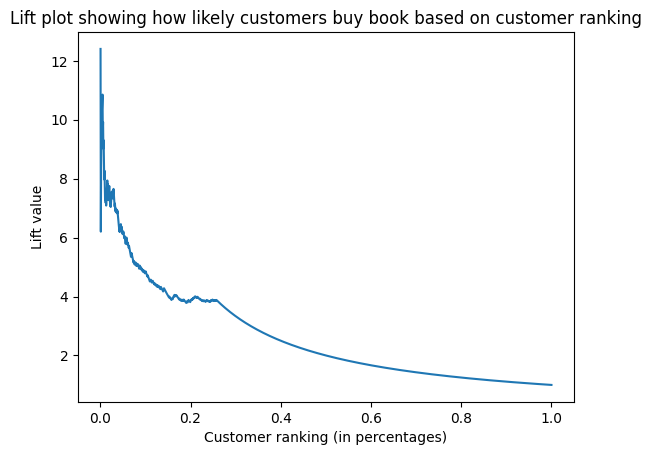

In [28]:
plt.plot(lift_df['percent_customers'] ,lift_df['lift'])
plt.title("Lift plot showing how likely customers buy book based on customer ranking")
plt.xlabel('Customer ranking (in percentages)')
plt.ylabel('Lift value'); 

###2.2 The k-NN prediction algorithm gives a numerical value, which is a weighted average of the
values of the Florence variable for the k-NN with weights that are inversely proportional to
distance. Using the best k that you calculated above with k-NN classification, now run a model
with k-NN prediction and compute a lift curve for the validation data. Use all 5 predictors and
normalized data. What is the range within which a prediction will fall? How does this result
compare to the output you get with the k-NN classification?

In [29]:
knn_weighted = Pipeline([ 
    ('scaler' , preprocessing.StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance')),
])
knn_weighted.fit(X_val, y_val)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(n_neighbors=7, weights='distance'))])

In [30]:
proba = knn_weighted.predict_proba(X_val)[:, 1] #this is a vector put it in a df so we can sort the values

lift_df = pd.DataFrame({
    'actual': y_val,
    'probability': proba
})
#sort those probability values
lift_df = lift_df.sort_values(by='probability', ascending=False)
lift_df

,actual,probability
517,1,1.0
2851,1,1.0
3761,1,1.0
3022,1,1.0
1687,1,1.0
...,...,...
130,0,0.0
3432,0,0.0
1123,0,0.0
1342,0,0.0


In [31]:
#https://www.geeksforgeeks.org/data-analysis/understanding-gain-chart-and-lift-chart/ This website help me understand what a lift curve is.
#I used AI to help me implement the lift equation for this data. 

#lift equation: Lift= Cumulative number of positive observations upto decile i using random model/
                     #Cumulative number of positive observations upto decile i using ML model

lift_df['cumulative_actual'] = lift_df['actual'].cumsum() #cumulative sum is stacking percents together by adding them one by one.
#We do this to get a steady rate in the plot.

total_positives = lift_df['actual'].sum() 

#the cumulative gain tells us how many customers we can potentially find and target based on the cumsum
lift_df['cumulative_gain'] = ( 
    lift_df['cumulative_actual'] / total_positives
)

#shows where in the ranking order of customers are you (first being very likely; last being not likely)
lift_df['percent_customers'] = ( 
    (np.arange(len(lift_df)) + 1) / len(lift_df)
)

lift_df['lift'] = (
    lift_df['cumulative_gain'] /
    lift_df['percent_customers']
)

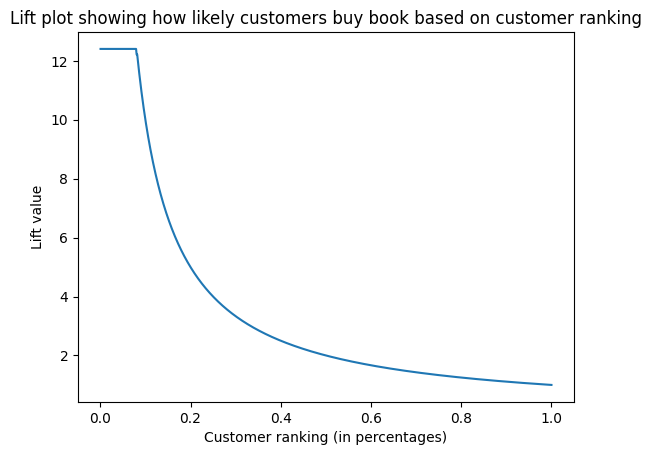

In [32]:
plt.plot(lift_df['percent_customers'] ,lift_df['lift'])
plt.title("Lift plot showing how likely customers buy book based on customer ranking")
plt.xlabel('Customer ranking (in percentages)')
plt.ylabel('Lift value'); 

The differences between the first and second lift charts are quite different. Using weights set
to distance creates a smoother curve because each neighbor contributes a different amount to the prediction based on its distance from the customer. 
The original KNN classification model uses uniform weights, meaning that each of the k neighbors contributes equally to the prediction.

Question 3 - Logistic Regression
The logistic regression model offers a powerful method for modeling response because it yields
well-defined purchase probabilities. The model is especially attractive in consumer-choice
settings because it can be derived from the random utility theory of consumer behavior.
3.1 Use the training set data of 2,400 records to construct two logistic regression models with
Florence as the outcome variable, using each of the following sets of predictors:
• Model A: The full set of 16 predictors in the dataset
• Model B: A subset of predictors that you judge to be the best

In [39]:
y = trainData['Yes_Florence']
X = trainData.drop(columns=['Yes_Florence', 'No_Florence', 'Seq#', 'ID#', 'Mcode', 'Rcode', 'Fcode', 'RFM_combinations', 'Gender'])

model_A = LogisticRegression(penalty="l2")
model_A.fit(X, y)

X_best = trainData[['M','R','F', 'Related Purchase']]

model_B = LogisticRegression(penalty="l2")
model_B.fit(X_best, y)

LogisticRegression(C=1e+42)

In [40]:
X_modelA = sm.add_constant(X)
X_modelA = sm.Logit(y, X_modelA).fit()
X_modelB = sm.add_constant(X_best)
X_modelB = sm.Logit(y, X_modelB).fit()

print("Model A AIC:", X_modelA.aic)
print("Model B AIC:", X_modelB.aic)

         Current function value: 0.000611
         Iterations: 35
Optimization terminated successfully.
         Current function value: 0.288888
         Iterations 7
Model A AIC: 34.933916657846595
Model B AIC: 1396.6604599963687


C:\Users\samsc\AppData\Roaming\Python\Python313\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\samsc\AppData\Roaming\Python\Python313\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\samsc\AppData\Roaming\Python\Python313\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\samsc\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Lik

A Lower AIC means that the model performs better, which means tht the other predictors that I presummed to not be that useful are in fact very useful for 
predicting customer behavior.

###3.2 If the cutoff criterion for a campaign is a 30% likelihood of a purchase, find the customers in
the validation data that would be targeted and count the number of buyers in this set

In [44]:
y_val = validationData['Yes_Florence']
X_val = validationData.drop(columns=['Yes_Florence', 'No_Florence', 'Seq#', 'ID#', 'Mcode', 'Rcode', 'Fcode', 'RFM_combinations', 'Gender'])

model_A_val = LogisticRegression(penalty="l2")
model_A_val.fit(X_val, y_val)

proba = model_A_val.predict_proba(X_val)[:,1]

proba_df = pd.DataFrame({'actual': validationData['Yes_Florence'], 'probability': proba})

#Create boolean mask of cutoff > 30%
cust_30 = proba_df[proba_df['probability'] > 0.30]
num_buyers = len(cust_30)
num_buyers

C:\Users\samsc\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


129